# Word Order Large Experiments


## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import re

import dotenv
import evaluate
import numpy as np
import openai
import pandas as pd
import pyrootutils
import tiktoken
from tokenizers import Tokenizer

PROJECT_ROOT = path = pyrootutils.find_root(indicator=".project-root")
DATA_DIR = PROJECT_ROOT / "data"
BATCHES_DIR = PROJECT_ROOT / "batches"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
FIGURES_DIR = NOTEBOOKS_DIR / "figures"
DATA_EXP_DIR = DATA_DIR / "wordorder_large_exp"
EXP_DIR = BATCHES_DIR / "wordorder_large_exp"

# create figures directory if it does not exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

dotenv.load_dotenv(PROJECT_ROOT / ".env")


True

## Define aesthetics

In [3]:
import aesthetics as aes  # noqa: F401

sns = aes.sns
mtick = aes.mtick
plt = aes.plt

aes.PALETTE_METRICS
aes.PALETTE_MODELS

WORD_ORDER_PLOT_ORDER = ["SVO", "SOV", "OVS"]
WORD_ORDER_PLOT_LABELS = {
    "SVO": "SVO \u2192 SVO",
    "SOV": "SVO \u2192 SOV",
    "OVS": "SVO \u2192 OVS",
}

# Set to a concrete model name to force plotting that model.
# Leave as None to auto-select from available rows.
PLOT_MODEL = None


## Grammars & Samples

<Axes: ylabel='n_words'>

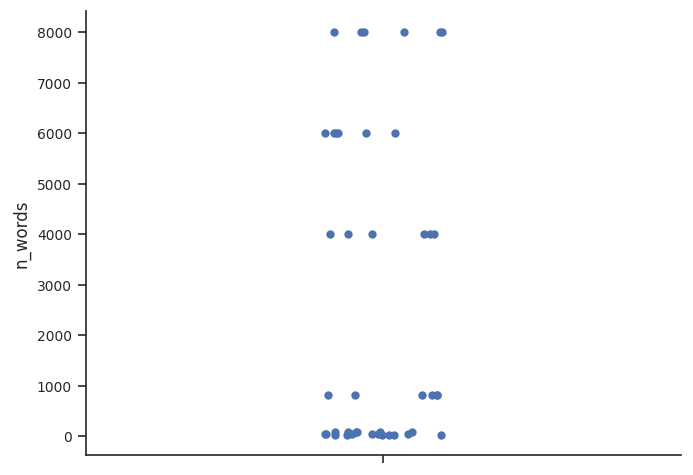

In [4]:
EXPERIMENT_GRAMMARS = DATA_EXP_DIR / "wordorder_large_grammars.txt"

grammar_ids = []
with open(EXPERIMENT_GRAMMARS, "r") as f:
    grammar_ids = [line.strip() for line in f.readlines()]

grammar_files = [f"grammar_{gid}.json" for gid in grammar_ids]
sample_files = [f"samples_{gid}.jsonl" for gid in grammar_ids]

grammars = []
for gf in grammar_files:
    with open(DATA_EXP_DIR / gf, "r") as f:
        grammars.append(json.load(f))

samples = []
for path in sample_files:
    grammar_name = path.split("samples_")[1].split(".jsonl")[0]
    with open(DATA_EXP_DIR / path, "r") as f:
        for sample_id, line in enumerate(f):
            sample = json.loads(line)
            sample["grammar_name"] = grammar_name
            sample["sample_id"] = str(sample_id)
            samples.append(sample)

samples_df = pd.DataFrame(samples)
samples_df["input_length"] = samples_df["left_phonetic"].apply(lambda x: len(x.split()))

grammar_sizes = pd.DataFrame(
    [{"name": g["name"], "n_words": g["n_words"]} for g in grammars]
)
sns.stripplot(grammar_sizes["n_words"])


<Axes: xlabel='depth', ylabel='Count'>

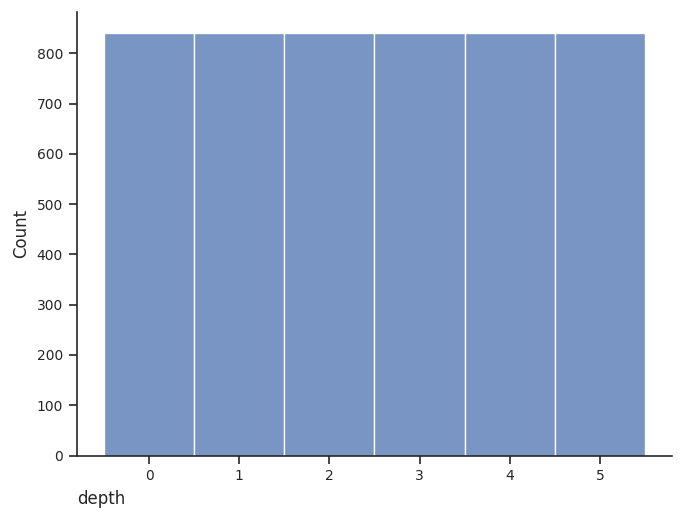

In [5]:
sns.histplot(samples_df["depth"], discrete=True)

## Outputs

In [6]:
openai_client = openai.OpenAI()

tokenizers = {
    "gpt-5-nano": tiktoken.encoding_for_model("gpt-5-nano"),
    "gpt-5-mini": tiktoken.encoding_for_model("gpt-5-mini"),
    "gpt-5": tiktoken.encoding_for_model("gpt-5"),
    "gemini-2.5-flash": Tokenizer.from_pretrained("google/gemma-3-1b-it"),
    "gemini-2.5-pro": Tokenizer.from_pretrained("google/gemma-3-1b-it"),
}


def fuzzy_model(model: str) -> str:
    # strip off the thing that looks like a date
    return re.sub(r"-\d{4}-\d{2}-\d{2}", "", model)

In [7]:
outputs_glob = sorted(EXP_DIR.glob("*_output.jsonl"))
inputs_glob = sorted(EXP_DIR.glob("inputs_*.jsonl"))

output_frames = []
for path in outputs_glob:
    df = pd.read_json(path, lines=True)
    json_struct = json.loads(df.to_json(orient="records"))
    flat_df = pd.json_normalize(json_struct)
    if flat_df.empty:
        continue

    flat_df["batch_id"] = path.name.split("_output.jsonl")[0]
    flat_df["model_response"] = flat_df["response.body.choices"].apply(
        lambda x: x[0]["message"]["content"] if isinstance(x, list) and x else None
    )
    flat_df["model"] = flat_df["response.body.model"]

    if flat_df["model"].iloc[0].startswith("gpt"):
        flat_df["prompt_tokens"] = flat_df["response.body.usage.prompt_tokens"]
        flat_df["completion_tokens"] = flat_df["response.body.usage.completion_tokens"]
        flat_df["total_tokens"] = flat_df["response.body.usage.total_tokens"]
    elif flat_df["model"].iloc[0].startswith("gemini"):
        flat_df["prompt_tokens"] = flat_df["response.body.usage.promptTokens"]
        flat_df["completion_tokens"] = flat_df["response.body.usage.completionTokens"]
        flat_df["total_tokens"] = flat_df["response.body.usage.totalTokens"]

    output_frames.append(flat_df)

if not output_frames:
    raise FileNotFoundError(f"No batch output files found in {EXP_DIR}")

outputs_df = pd.concat(output_frames, ignore_index=True)
outputs_df = outputs_df.drop(
    [col for col in outputs_df.columns if col.startswith("response")], axis=1
).drop(columns=["error"], errors="ignore")

input_frames = []
for path in inputs_glob:
    df = pd.read_json(path, lines=True)
    json_struct = json.loads(df.to_json(orient="records"))
    flat_df = pd.json_normalize(json_struct)
    if flat_df.empty:
        continue

    flat_df["input_file"] = path.name
    flat_df["grammar_name"] = flat_df["body.metadata.grammar_name"]
    flat_df["sample_id"] = flat_df["body.metadata.sample_id"].astype(str)
    flat_df["depth"] = flat_df["body.metadata.depth"].astype(int)
    input_frames.append(flat_df)

if not input_frames:
    raise FileNotFoundError(f"No batch input files found in {EXP_DIR}")

inputs_df = pd.concat(input_frames, ignore_index=True).drop(
    columns=["body.max_completion_tokens"], errors="ignore"
)

merged_df = pd.merge(
    outputs_df,
    inputs_df[["custom_id", "input_file", "grammar_name", "sample_id", "depth"]],
    on="custom_id",
    how="inner",
)

merged_df = pd.merge(
    merged_df,
    samples_df[["grammar_name", "sample_id", "left_phonetic", "right_phonetic"]].rename(
        columns={
            "left_phonetic": "input_sentence",
            "right_phonetic": "output_sentence",
        }
    ),
    on=["grammar_name", "sample_id"],
    how="left",
)

merged_df["fuzzy_model"] = merged_df["model"].apply(fuzzy_model)


In [8]:
grammar_blobs = DATA_EXP_DIR.glob("grammar_*.json")
grammars = []

for path in grammar_blobs:
    with open(path, "r") as f:
        grammar = json.load(f)
        grammar_name = path.name.split("grammar_")[1].split(".json")[0]
        grammar["grammar_name"] = grammar_name
        grammar = pd.json_normalize(grammar)

        grammar["a.words"] = grammar[
            [
                "a.verbs",
                "a.nouns",
                "a.propns",
                "a.prons",
                "a.adjs",
                "a.det_def",
                "a.det_indef",
                "a.comps",
            ]
        ].apply(lambda row: sum(row, []), axis=1)
        grammar["b.words"] = grammar[
            [
                "b.verbs",
                "b.nouns",
                "b.propns",
                "b.prons",
                "b.adjs",
                "b.det_def",
                "b.det_indef",
                "b.comps",
            ]
        ].apply(lambda row: sum(row, []), axis=1)

        grammar["share_head"] = grammar["a.head_initial"] == grammar["b.head_initial"]
        grammar["share_spec"] = grammar["a.spec_initial"] == grammar["b.spec_initial"]

        def categorize(row) -> str:
            if row["share_head"] and row["share_spec"]:
                return "all-same"
            elif row["share_head"] and not row["share_spec"]:
                return "spec-diff"
            elif not row["share_head"] and row["share_spec"]:
                return "head-diff"
            else:
                return "all-diff"

        grammar["word_order_type"] = grammar.apply(categorize, axis=1)
        grammar["target_word_order"] = grammar["word_order_type"].map(
            {
                "all-same": "SVO",
                "head-diff": "SOV",
                "all-diff": "OVS",
                "spec-diff": "VOS",
            }
        )

        grammar["syllable_structure"] = grammar["a.syllable_structure"]

        grammar = grammar.drop(
            columns=[
                "a.head_initial",
                "b.head_initial",
                "a.spec_initial",
                "b.spec_initial",
                "a.pro_drop",
                "b.pro_drop",
                "a.syllable_structure",
                "b.syllable_structure",
            ]
        )

        grammars.append(grammar)

grammars_df = pd.concat(grammars, ignore_index=True)

merged_df = pd.merge(
    merged_df,
    grammars_df[
        [
            "share_head",
            "share_spec",
            "word_order_type",
            "target_word_order",
            "grammar_name",
            "syllable_structure",
            "n_rules",
            "n_words",
            "a.words",
            "b.words",
        ]
    ],
    on="grammar_name",
)

merged_df["input_tokens"] = merged_df.apply(
    lambda row: len(
        tokenizers[fuzzy_model(row["model"])].encode(row["input_sentence"])
    ),
    axis=1,
)
merged_df["output_tokens"] = merged_df.apply(
    lambda row: len(
        tokenizers[fuzzy_model(row["model"])].encode(row["output_sentence"])
    ),
    axis=1,
)


### Extract Answer

In [9]:
answer_re = re.compile(
    r"final\s*answer\s*(?::|-|—)?\s*(?:is\s*)?([^\n]+)",
    re.DOTALL | re.IGNORECASE,
)


def extract_answer(model_response):
    matches = answer_re.findall(model_response)
    if matches:
        last_match: str = matches[-1]
        last_match = re.sub(r"[^a-zA-Z\s]", "", last_match)
        last_match = last_match.strip()
        return last_match
    else:
        return None


merged_df = merged_df.drop_duplicates(subset=["custom_id", "batch_id"])
merged_df["model_answer"] = merged_df["model_response"].apply(extract_answer)

In [10]:
# Check how many entries there are where model_answer is null per model
null_answers = merged_df[merged_df["model_answer"].isna()]
null_answers.groupby("fuzzy_model").size()

fuzzy_model
gpt-5-nano    35
dtype: int64

### Compute Metrics

In [11]:
# metrics
try:
    import sacrebleu
except ImportError:
    sacrebleu = None


def exact_match(row) -> bool:
    if row["model_answer"] is None or row["output_sentence"] is None:
        return False
    return row["model_answer"] == row["output_sentence"]


def bow_match(row) -> bool:
    if row["model_answer"] is None or row["output_sentence"] is None:
        return False
    return sorted(row["model_answer"].split()) == sorted(row["output_sentence"].split())


def edit_similarity(row) -> float:
    if row["model_answer"] is None or row["output_sentence"] is None:
        return 1.0
    from strsimpy.jaro_winkler import JaroWinkler

    jw = JaroWinkler()
    return 1 - jw.distance(row["model_answer"], row["output_sentence"])


def bleu(row) -> float:
    if sacrebleu is None:
        return np.nan
    pred = row["model_answer"] or ""
    ref = row["output_sentence"] or ""
    return sacrebleu.sentence_bleu(pred, [ref]).score / 100.0


def num_oov_words(row) -> int:
    if row["model_answer"] is None or row["output_sentence"] is None:
        return np.nan
    model_words: set[str] = set(row["model_answer"].split())
    output_words: set[str] = set(row["b.words"])
    oov_words: set[str] = model_words - output_words
    return len(oov_words)


# Metrics
merged_df["exact_match"] = merged_df.apply(exact_match, axis=1)
merged_df["bow_match"] = merged_df.apply(bow_match, axis=1)
merged_df["edit_similarity"] = merged_df.apply(edit_similarity, axis=1)
merged_df["num_oov_words"] = merged_df.apply(num_oov_words, axis=1)
merged_df["bleu"] = merged_df.apply(bleu, axis=1)

# manually calculate chrF and chrF++
preds = merged_df["model_answer"].tolist()
refs = merged_df["output_sentence"].tolist()

chrf = evaluate.load("chrf")
chrfScores: list[float] = []
chrfPPScores: list[float] = []
for pred, ref in zip(preds, refs):
    if pred is None:
        pred = ""
    if ref is None:
        ref = ""
    chrfScores.append(
        chrf.compute(
            predictions=[pred],
            references=[[ref]],
            beta=2,
            word_order=0,
        )
    )
    chrfPPScores.append(
        chrf.compute(
            predictions=[pred],
            references=[[ref]],
            beta=2,
            word_order=2,
        )
    )
merged_df["chrF"] = [score["score"] / 100.0 for score in chrfScores]
merged_df["chrF++"] = [score["score"] / 100.0 for score in chrfPPScores]

merged_df["input_words"] = merged_df["input_sentence"].apply(lambda x: len(x.split()))
merged_df["input_words_rounded5"] = merged_df["input_words"].apply(
    lambda x: round(x / 5) * 5
)
merged_df["size"] = merged_df.apply(
    lambda row: int(row["n_rules"]) + int(row["n_words"]),
    axis=1,
)

merged_df["ttc"] = merged_df["completion_tokens"]
merged_df["ttc_binned"] = merged_df["ttc"].apply(
    # log2
    lambda x: round(np.log10(x)) if x > 0 else 0
)

metrics_df = merged_df.melt(
    id_vars=[
        "model",
        "input_words_rounded5",
        "input_words",
        "custom_id",
        "model_answer",
        "output_sentence",
        "depth",
        "size",
        "ttc",
        "ttc_binned",
        "syllable_structure",
        "share_spec",
        "share_head",
        "word_order_type",
        "target_word_order",
        "input_tokens",
        "output_tokens",
    ],
    value_vars=[
        "exact_match",
        "bow_match",
        "edit_similarity",
        "num_oov_words",
        "bleu",
        "chrF",
        "chrF++",
    ],
    var_name="match_type",
    value_name="match_value",
)

# rename `exact_match` and `bow_match` in match_type column
metrics_df["match_type"] = metrics_df["match_type"].replace(
    {
        "exact_match": "Exact Match",
        "bow_match": "Bag of Words",
        "edit_similarity": "Edit Similarity",
        "num_oov_words": "Num OOV Words",
        "bleu": "BLEU Score",
        "chrF++": "chrF++",
        "chrF": "chrF",
    }
)

metrics_df["input_tokens_rounded"] = metrics_df["input_tokens"].apply(
    lambda x: round(x / 5) * 5
)
metrics_df["output_tokens_rounded"] = metrics_df["output_tokens"].apply(
    lambda x: round(x / 5) * 5
)
metrics_df["token_delta"] = abs(
    metrics_df["output_tokens"] - metrics_df["input_tokens"]
)
metrics_df["token_delta_norm"] = abs(
    metrics_df["output_tokens"] - metrics_df["input_tokens"]
) / metrics_df["input_tokens"].replace(0, np.nan)
metrics_df["token_delta_norm_rounded"] = metrics_df["token_delta_norm"].apply(
    lambda x: round(x, 1)
)

# convert the `model` column to an ordered categorical type
metrics_df["model_name"] = metrics_df["model"].apply(lambda x: fuzzy_model(x))
metrics_df["model_name"] = pd.Categorical(
    metrics_df["model_name"],
    categories=[
        "gpt-5-nano",
        "gpt-5-mini",
        "gpt-5",
        "gemini-2.5-flash",
        "gemini-2.5-pro",
    ],
    ordered=True,
)


In [12]:
metrics_df["model_name"].unique()

['gpt-5-nano', 'gpt-5', 'gpt-5-mini']
Categories (5, object): ['gpt-5-nano' < 'gpt-5-mini' < 'gpt-5' < 'gemini-2.5-flash' < 'gemini-2.5-pro']

## Plots

### Input length distribution

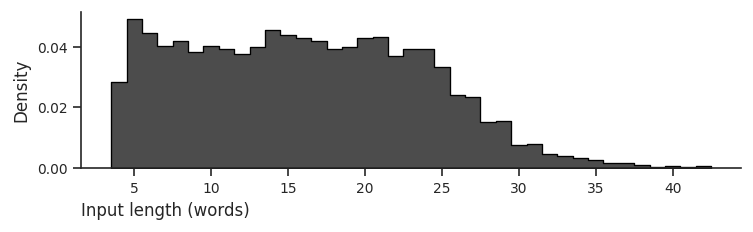

In [13]:
fig = plt.figure(figsize=(aes.PAPER_WIDTH_IN, aes.FIG_HEIGHT_SINGLEROW_IN))
grid = fig.add_gridspec(1, 1, wspace=0.1)
ax = fig.add_subplot(grid[0, 0])

with sns.plotting_context("paper", font_scale=1, rc=aes.rcs):
    sns.histplot(
        data=metrics_df,
        x="input_words",
        discrete=True,
        stat="density",
        element="step",
        color="black",
        alpha=0.7,
        ax=ax,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlabel("Input length (words)", loc="left")
    ax.set_ylabel("Density")

plt.subplots_adjust(left=0, bottom=0, right=1, top=1)

plt.savefig(
    FIGURES_DIR / "wordorder_large_input_length_distribution.pdf",
    bbox_inches="tight",
)

### Sentential Complexity

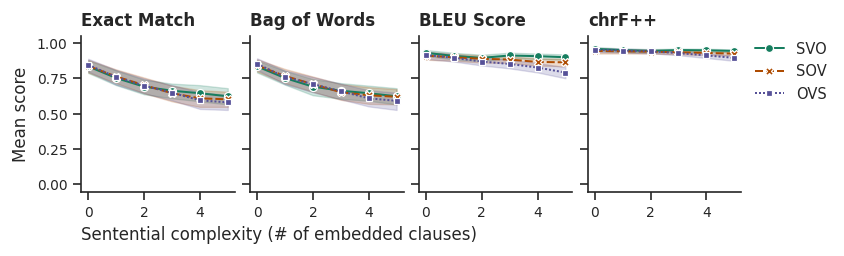

In [14]:
fig = plt.figure(figsize=(aes.PAPER_WIDTH_IN, aes.FIG_HEIGHT_SINGLEROW_IN))

with sns.plotting_context("paper", font_scale=1, rc=aes.rcs):
    PERF_METRICS = ["Exact Match", "Bag of Words", "BLEU Score", "chrF++"]
    grid = fig.add_gridspec(1, len(PERF_METRICS), wspace=0.1)

    for i, pm in enumerate(PERF_METRICS):
        ax = fig.add_subplot(grid[0, i])

        sns.lineplot(
            data=metrics_df[
                (metrics_df["model_name"] == "gpt-5") & (metrics_df["match_type"] == pm)
            ],
            x="depth",
            y="match_value",
            hue="target_word_order",
            style="target_word_order",
            markers=True,
            ax=ax,
            palette=aes.PALETTE_WORDORDER,
            legend=True,
            errorbar="ci",
        )

        ax.set_ylim(-0.05, 1.05)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_title(pm)

        if i == 0:
            ax.set_xlabel("Sentential complexity (# of embedded clauses)", loc="left")
            ax.set_ylabel("Mean score")
            # ax.yaxis.set_major_formatter(aes.PCT_FORMATTER)
        else:
            ax.set_ylabel("")
            ax.yaxis.set_ticklabels([])
            ax.set_xlabel("")

        if i == len(PERF_METRICS) - 1:
            ax.legend(
                title="",
                bbox_to_anchor=(1.05, 1.0),
                loc="upper left",
                borderaxespad=0,
                frameon=False,
            )
        else:
            ax.get_legend().remove()


plt.subplots_adjust(left=0, bottom=0, right=1, top=1)

plt.savefig(
    FIGURES_DIR / "wordorder_large_sentential_complexity_lineplot_ci.pdf",
    bbox_inches="tight",
)

In [15]:
# count number of observations per model and depth
metrics_df[metrics_df["match_type"] == "Exact Match"].groupby(
    ["model_name", "depth"], observed=True
).size().value_counts()

840    18
Name: count, dtype: int64

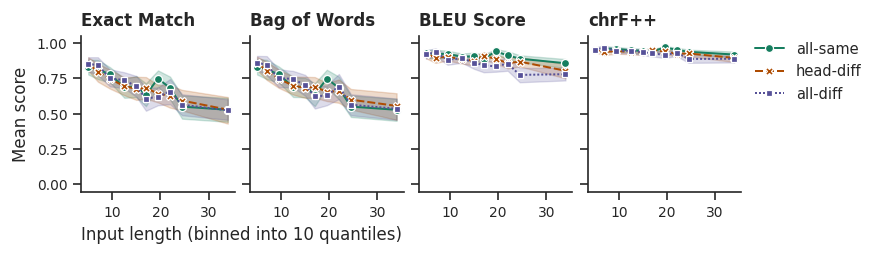

In [16]:
fig = plt.figure(figsize=(aes.PAPER_WIDTH_IN, aes.FIG_HEIGHT_SINGLEROW_IN))

# Bin input_words into quintiles
N_BINS = 10
metrics_df["input_words_binned_quant"] = pd.qcut(
    metrics_df["input_words"],
    q=N_BINS,
    duplicates="drop",
)
metrics_df["input_words_binned_quant_num"] = metrics_df[
    "input_words_binned_quant"
].apply(lambda x: (x.left + x.right) / 2)

# round to nearest 5
metrics_df["input_words_binned"] = metrics_df["input_words"].apply(
    lambda x: round(x / 10) * 10
)

with sns.plotting_context("paper", font_scale=1, rc=aes.rcs):
    PERF_METRICS = ["Exact Match", "Bag of Words", "BLEU Score", "chrF++"]
    grid = fig.add_gridspec(1, len(PERF_METRICS), wspace=0.1)

    for i, pm in enumerate(PERF_METRICS):
        ax = fig.add_subplot(grid[0, i])

        sns.lineplot(
            data=metrics_df[
                (metrics_df["model_name"] == "gpt-5") & (metrics_df["match_type"] == pm)
            ],
            x="input_words_binned_quant_num",
            y="match_value",
            hue="word_order_type",
            style="word_order_type",
            markers=True,
            ax=ax,
            palette=aes.PALETTE_WORDORDER,
            legend=True,
            errorbar="ci",
        )

        ax.set_ylim(-0.05, 1.05)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_title(pm)

        # ax.set_xticks([0, 10, 20, 30, 40])

        if i == 0:
            ax.set_xlabel("Input length (binned into 10 quantiles)", loc="left")
            ax.set_ylabel("Mean score")
            # ax.yaxis.set_major_formatter(aes.PCT_FORMATTER)
        else:
            ax.set_ylabel("")
            ax.yaxis.set_ticklabels([])
            ax.set_xlabel("")

        if i == len(PERF_METRICS) - 1:
            ax.legend(
                title="",
                bbox_to_anchor=(1.05, 1.0),
                loc="upper left",
                borderaxespad=0,
                frameon=False,
            )
        else:
            ax.get_legend().remove()


plt.subplots_adjust(left=0, bottom=0, right=1, top=1)

plt.savefig(
    FIGURES_DIR / "wordorder_large_sentential_complexity_length_lineplot_ci.pdf",
    bbox_inches="tight",
)

In [17]:
# count number of observations per model and depth
metrics_df[metrics_df["match_type"] == "Exact Match"].groupby(
    ["model_name", "input_words_binned_quant_num"], observed=True
).size().value_counts()

615    3
414    3
593    3
621    3
438    3
409    3
635    3
384    3
485    3
446    3
Name: count, dtype: int64

### Grammatical Complexity

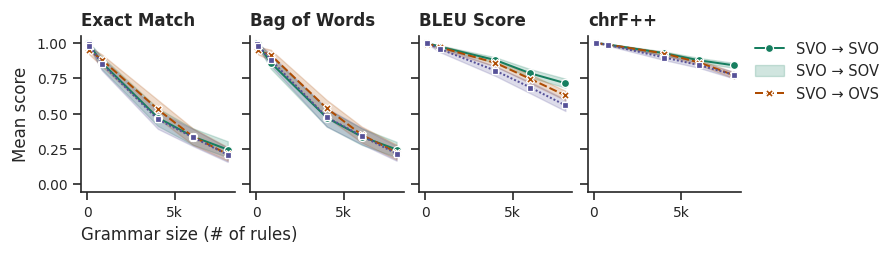

In [18]:
fig = plt.figure(figsize=(aes.PAPER_WIDTH_IN, aes.FIG_HEIGHT_SINGLEROW_IN))

with sns.plotting_context("paper", font_scale=1, rc=aes.rcs):
    PERF_METRICS = ["Exact Match", "Bag of Words", "BLEU Score", "chrF++"]
    grid = fig.add_gridspec(1, len(PERF_METRICS), wspace=0.1)

    for i, pm in enumerate(PERF_METRICS):
        ax = fig.add_subplot(grid[0, i])

        sns.lineplot(
            data=metrics_df[
                (metrics_df["model_name"] == "gpt-5") & (metrics_df["match_type"] == pm)
            ],
            x="size",
            y="match_value",
            hue="target_word_order",
            style="target_word_order",
            markers=True,
            ax=ax,
            palette=aes.PALETTE_WORDORDER,
            legend=True,
            errorbar="ci",
        )

        ax.set_ylim(-0.05, 1.05)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_title(pm)

        # log scale on x-axis?
        # ax.set_xscale("log")
        ax.xaxis.set_major_formatter(aes.NICE_FORMATTER)
        # ax.set_xticks([500, 1000])
        # ax.set_xticklabels([500, 1000])

        if i == 0:
            ax.set_xlabel("Grammar size (# of rules)", loc="left")
            ax.set_ylabel("Mean score")
            # ax.yaxis.set_major_formatter(aes.PCT_FORMATTER)
        else:
            ax.set_ylabel("")
            ax.yaxis.set_ticklabels([])
            ax.set_xlabel("")

        if i == len(PERF_METRICS) - 1:
            ax.legend(
                title="",
                bbox_to_anchor=(1.05, 1.0),
                loc="upper left",
                borderaxespad=0,
                frameon=False,
                labels=["SVO \u2192 SVO", "SVO \u2192 SOV", "SVO \u2192 OVS"],
            )
        else:
            ax.get_legend().remove()

plt.subplots_adjust(left=0, bottom=0, right=1, top=1)

plt.savefig(
    FIGURES_DIR / "wordorder_large_grammatical_complexity_lineplot_ci.pdf",
    bbox_inches="tight",
)

In [19]:
# count number of observations per model and grammar size
metrics_df[metrics_df["match_type"] == "Exact Match"].groupby(
    ["model_name", "size"], observed=True
).size().value_counts()

720    21
Name: count, dtype: int64

### Grammatical & Sentential Complexity

In [33]:
PLOT_MODEL = "gpt-5"
# PLOT_MODEL = None


In [34]:
if len(metrics_df):
    PERF_METRICS = ["Exact Match", "Bag of Words", "BLEU Score", "chrF++"]

    metrics_df["input_length_quintile"] = pd.qcut(
        metrics_df["input_words"],
        q=5,
        duplicates="drop",
    )
    metrics_df["input_length_quintile_mid"] = metrics_df["input_length_quintile"].apply(
        lambda x: (x.left + x.right) / 2
    )

    plot_model_candidates = [
        model
        for model in metrics_df["model_name"].cat.categories
        if (metrics_df["model_name"] == model).any()
    ]
    if PLOT_MODEL is None:
        selected_model = plot_model_candidates[-1] if plot_model_candidates else None
    else:
        selected_model = PLOT_MODEL
    print(f"Plotting model: {selected_model}")

    plot_source_df = metrics_df[
        (metrics_df["model_name"] == selected_model)
        & (metrics_df["match_type"].isin(PERF_METRICS))
    ].copy()
    plot_source_df["target_word_order"] = pd.Categorical(
        plot_source_df["target_word_order"],
        categories=WORD_ORDER_PLOT_ORDER,
        ordered=True,
    )

    plot_length_df = plot_source_df.copy()
    plot_size_df = plot_source_df.copy()
else:
    plot_length_df = pd.DataFrame()
    plot_size_df = pd.DataFrame()
    selected_model = None


Plotting model: gpt-5


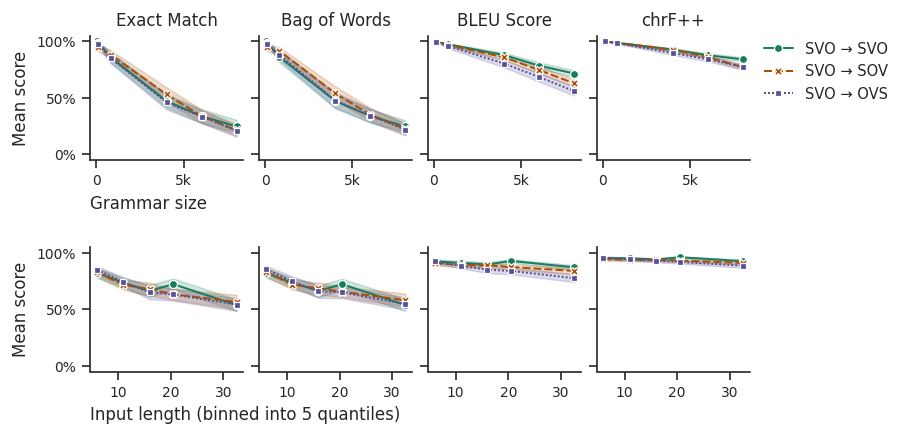

In [35]:
if len(plot_length_df):
    fig = plt.figure(figsize=(aes.PAPER_WIDTH_IN, aes.FIG_HEIGHT_DOUBLEROW_DIFFAXES_IN))
    grid = fig.add_gridspec(2, len(PERF_METRICS), wspace=0.1, hspace=0.7)

    with sns.plotting_context("paper", font_scale=1, rc=aes.rcs):
        for r in range(2):
            for i, metric_name in enumerate(PERF_METRICS):
                ax = fig.add_subplot(grid[r, i])

                if r == 1:
                    sns.lineplot(
                        data=plot_length_df[
                            plot_length_df["match_type"] == metric_name
                        ],
                        x="input_length_quintile_mid",
                        y="match_value",
                        hue="target_word_order",
                        style="target_word_order",
                        hue_order=WORD_ORDER_PLOT_ORDER,
                        style_order=WORD_ORDER_PLOT_ORDER,
                        markers=True,
                        ax=ax,
                        palette=aes.PALETTE_WORDORDER,
                        legend=True,
                        errorbar="ci",
                    )
                    ax.set_xlabel(
                        "Input length (binned into 5 quantiles)",
                        loc="left" if i == 0 else "center",
                    )
                else:
                    sns.lineplot(
                        data=plot_size_df[plot_size_df["match_type"] == metric_name],
                        x="size",
                        y="match_value",
                        hue="target_word_order",
                        style="target_word_order",
                        hue_order=WORD_ORDER_PLOT_ORDER,
                        style_order=WORD_ORDER_PLOT_ORDER,
                        markers=True,
                        ax=ax,
                        palette=aes.PALETTE_WORDORDER,
                        legend=True,
                        errorbar="ci",
                    )
                    ax.set_xlabel(
                        "Grammar size",
                        loc="left" if i == 0 else "center",
                    )
                    ax.xaxis.set_major_formatter(aes.NICE_FORMATTER)

                ax.set_ylim(-0.05, 1.05)
                ax.yaxis.set_major_formatter(aes.PCT_FORMATTER)
                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)
                if r == 0:
                    ax.set_title(metric_name, fontweight="normal", loc="center")

                if i == 0:
                    ax.set_ylabel("Mean score")
                else:
                    ax.set_ylabel("")
                    ax.yaxis.set_ticklabels([])
                    ax.set_xlabel("")

                if (i == len(PERF_METRICS) - 1) and (r == 0):
                    handles, labels = ax.get_legend_handles_labels()
                    label_to_handle = dict(zip(labels, handles))
                    ordered_levels = [
                        label
                        for label in WORD_ORDER_PLOT_ORDER
                        if label in label_to_handle
                    ]
                    ax.legend(
                        [label_to_handle[label] for label in ordered_levels],
                        [WORD_ORDER_PLOT_LABELS[label] for label in ordered_levels],
                        title="",
                        bbox_to_anchor=(1.05, 1.0),
                        loc="upper left",
                        borderaxespad=0,
                        frameon=False,
                    )
                else:
                    legend = ax.get_legend()
                    if legend is not None:
                        legend.remove()

    plt.subplots_adjust(left=0, bottom=0, right=1, top=1)
    plt.savefig(
        FIGURES_DIR / f"{selected_model}_wordorder_large.pdf", bbox_inches="tight"
    )
    plt.savefig(
        FIGURES_DIR / f"{selected_model}_wordorder_large.png",
        bbox_inches="tight",
        dpi=300,
    )

    plt.show()
else:
    print("No scored outputs available yet for plotting.")


### Predicted Translation Length

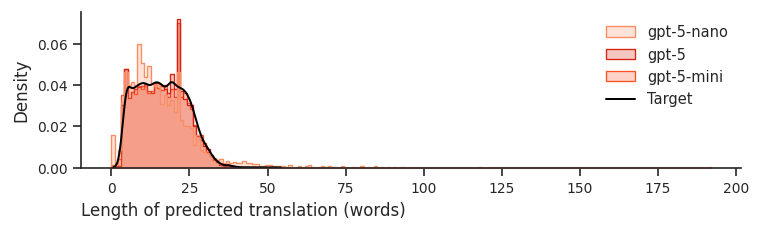

In [23]:
# histogram of "model_answer" lengths by model
merged_df["model_answer_length"] = merged_df["model_answer"].apply(
    lambda x: len(x.split()) if isinstance(x, str) else 0
)
merged_df["target_length"] = merged_df["output_sentence"].apply(
    lambda x: len(x.split()) if isinstance(x, str) else 0
)

with sns.plotting_context("paper", font_scale=1, rc=aes.rcs):
    fig = plt.figure(figsize=(aes.PAPER_WIDTH_IN, aes.FIG_HEIGHT_SINGLEROW_IN))
    grid = fig.add_gridspec(1, 1)
    ax = fig.add_subplot(grid[0, 0])

    sns.histplot(
        data=merged_df,
        x="model_answer_length",
        hue="fuzzy_model",
        element="step",
        stat="density",
        common_norm=False,
        palette=aes.PALETTE_MODELS,
        ax=ax,
    )

    sns.kdeplot(data=merged_df, x="target_length", color="black", ax=ax, label="Target")

    # Histplots are weird about legends. To get a combined legend for
    # both the histplot and the kdeplot, we have to manually merge them.
    old_legend = ax.legend_
    handles = old_legend.legend_handles
    labels = [text.get_text() for text in old_legend.texts]
    plt.legend()
    t_handle, t_label = ax.get_legend_handles_labels()
    handles = handles + t_handle[-1:]
    labels = labels + t_label[-1:]
    ax.legend(handles, labels, frameon=False)
    sns.move_legend(
        ax, "upper right", bbox_to_anchor=(1, 1.0), frameon=False, title=None
    )

    ax.set_xlabel("Length of predicted translation (words)", x=0, ha="left")

plt.subplots_adjust(left=0, bottom=0, right=1, top=1)

plt.savefig(
    FIGURES_DIR / "wordorder_large_predicted_translation_length.pdf",
    bbox_inches="tight",
)

### TTC

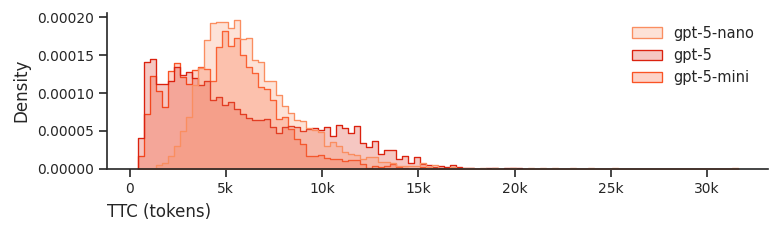

In [24]:
with sns.plotting_context("paper", font_scale=1, rc=aes.rcs):
    fig = plt.figure(figsize=(aes.PAPER_WIDTH_IN, aes.FIG_HEIGHT_SINGLEROW_IN))
    grid = fig.add_gridspec(1, 1)
    ax = fig.add_subplot(grid[0, 0])

    sns.histplot(
        data=merged_df,
        x="ttc",
        hue="fuzzy_model",
        element="step",
        stat="density",
        common_norm=False,
        palette=aes.PALETTE_MODELS,
        ax=ax,
    )

    ax.xaxis.set_major_formatter(aes.NICE_FORMATTER)

    sns.move_legend(
        ax, "upper right", bbox_to_anchor=(1, 1.0), frameon=False, title=None
    )

    ax.set_xlabel("TTC (tokens)", x=0, ha="left")

plt.subplots_adjust(left=0, bottom=0, right=1, top=1)

plt.savefig(
    FIGURES_DIR / "wordorder_large_ttc_distribution.pdf",
    bbox_inches="tight",
)